# Notebook for plotting evaluation metrics for drone swarm

Structure of the drone_data:

[# neighbors, avg neighbors dist, distance weight convex hull, viewing error, viewing coverage]

## Metrics definition
1. Neighbors average

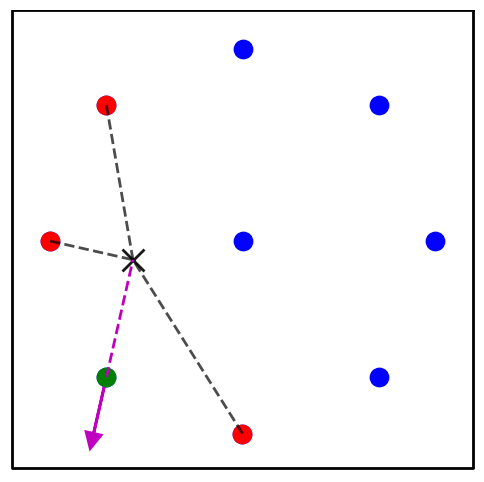

In [15]:
# Simple average of neighbors
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Show neighbors centroid
x_center = np.mean([x[i] for i in neighbors])
y_center = np.mean([y[i] for i in neighbors])
plt.scatter(x_center, y_center, marker='x', color=[[0,0,0,0.90]], s=250, linewidth=2)

# Draw dotted line from neighbors to centroid
for i in neighbors:
    plt.plot([x[i], x_center], [y[i], y_center], 'k--', alpha=0.7, lw=2)

# Draw dotted line from selected to centroid
plt.plot([x[selected], x_center], [y[selected], y_center], 'm--', lw=2, alpha=1)

# Draw pointing arrow
dir = np.array([x_center - x[selected], y_center - y[selected]])
dir = dir / np.linalg.norm(dir)
plt.arrow(x[selected], y[selected], -dir[0]*0.15, -dir[1]*0.15, head_width=0.04, head_length=0.04, fc='m', ec='m', linewidth=2)

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)


2. Convex Hull

CONVEX HULL ADJACENT


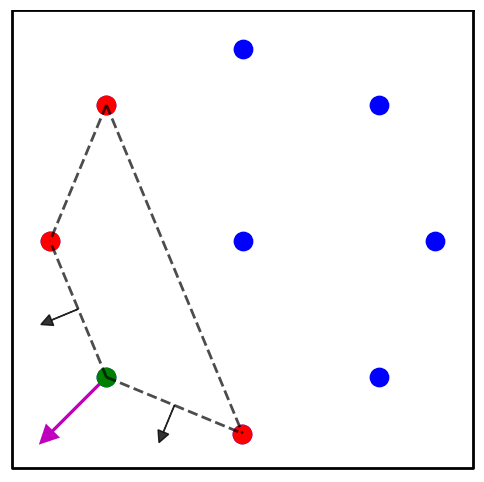

In [7]:
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Show convex hull of neighbors including selected drone
from scipy.spatial import ConvexHull
points = np.array([[x[i], y[i]] for i in neighbors] + [[x[selected], y[selected]]])
hull = ConvexHull(points)
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k--', alpha=0.7, lw=2)

# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Show arrows for adjacent edges of selected
# Select edges of selected drone
adjacent = [3,2]
# Draw arrows
hull_centroids = np.mean(points[hull.simplices], axis=1)
# draw normal of adjacent edges
final_dir = np.zeros(2)
for i in adjacent:
    dir = hull.equations[i,:2]
    dir = dir / np.linalg.norm(dir)
    final_dir += dir
    plt.arrow(hull_centroids[i,0], hull_centroids[i,1], dir[0]*0.075, dir[1]*0.075, head_width=0.03, head_length=0.03, fc='k', ec='k', alpha=0.8)

# # Draw pointing arrow
final_dir = final_dir / np.linalg.norm(final_dir)
plt.arrow(x[selected], y[selected], final_dir[0]*0.2, final_dir[1]*0.2, head_width=0.04, head_length=0.04, fc='m', ec='m', lw=2)

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

print("CONVEX HULL ADJACENT")

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)


CONVEX HULL VISIBLE


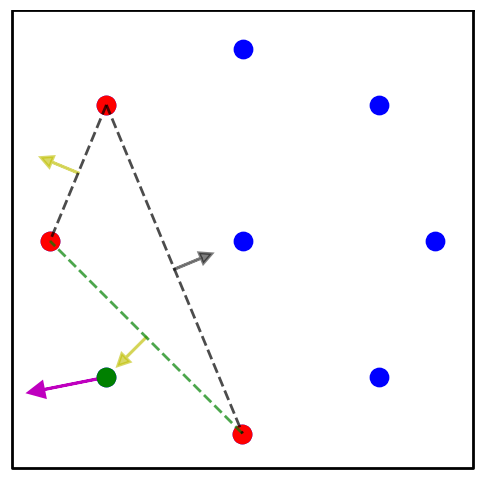

In [33]:
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Show convex hull of neighbors including selected drone
from scipy.spatial import ConvexHull
points = np.array([[x[i], y[i]] for i in neighbors])
hull = ConvexHull(points)

# Show edges normal using hull equations
hull_centroids = np.mean(points[hull.simplices], axis=1)
# Find closest to the drone
drone_pos = np.array([x[selected], y[selected]])
closest_idx = np.argmin(np.linalg.norm(hull_centroids - drone_pos, axis=1))
closest_normal = hull.equations[closest_idx, :2]

# for simplex in hull.simplices:
#     plt.plot(points[simplex, 0], points[simplex, 1], 'k--', alpha=0.75, lw=1)

visible_normals = []
for i in range(len(hull.equations)):
    # draw edge
    plt.plot([points[hull.simplices[i, 0], 0], points[hull.simplices[i, 1], 0]], [points[hull.simplices[i, 0], 1], points[hull.simplices[i, 1], 1], ], 'k--' if i != closest_idx else 'g--', alpha=0.7, lw=2)
    x0 = hull_centroids[i, 0]
    y0 = hull_centroids[i, 1]
    a = hull.equations[i, 0]
    b = hull.equations[i, 1]
    if np.dot(hull.equations[i, :2], closest_normal) > 0:
        visible_normals.append(hull.equations[i, :2])
        # Draw normal
        plt.arrow(x0, y0, a*0.075, b*0.075, head_width=0.03, head_length=0.03, fc='y', ec='y', alpha=0.6, lw=2)
    else:
        plt.arrow(x0, y0, a*0.075, b*0.075, head_width=0.03, head_length=0.03, fc='k', ec='k', alpha=0.5, linewidth=2)


# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# # Draw pointing arrow
final_dir = np.mean(visible_normals, axis=0)
plt.arrow(x[selected], y[selected], final_dir[0]*0.2, final_dir[1]*0.2, head_width=0.04, head_length=0.04, fc='m', ec='m', lw=2)

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

print("CONVEX HULL VISIBLE")
# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)


3. Outer

In [53]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Arc
from matplotlib.transforms import Bbox, IdentityTransform, TransformedBbox


class AngleAnnotation(Arc):
    """
    Draws an arc between two vectors which appears circular in display space.
    """
    def __init__(self, xy, p1, p2, size=75, unit="points", ax=None,
                 text="", textposition="inside", text_kw=None, **kwargs):
        """
        Parameters
        ----------
        xy, p1, p2 : tuple or array of two floats
            Center position and two points. Angle annotation is drawn between
            the two vectors connecting *p1* and *p2* with *xy*, respectively.
            Units are data coordinates.

        size : float
            Diameter of the angle annotation in units specified by *unit*.

        unit : str
            One of the following strings to specify the unit of *size*:

            * "pixels": pixels
            * "points": points, use points instead of pixels to not have a
              dependence on the DPI
            * "axes width", "axes height": relative units of Axes width, height
            * "axes min", "axes max": minimum or maximum of relative Axes
              width, height

        ax : `matplotlib.axes.Axes`
            The Axes to add the angle annotation to.

        text : str
            The text to mark the angle with.

        textposition : {"inside", "outside", "edge"}
            Whether to show the text in- or outside the arc. "edge" can be used
            for custom positions anchored at the arc's edge.

        text_kw : dict
            Dictionary of arguments passed to the Annotation.

        **kwargs
            Further parameters are passed to `matplotlib.patches.Arc`. Use this
            to specify, color, linewidth etc. of the arc.

        """
        self.ax = ax or plt.gca()
        self._xydata = xy  # in data coordinates
        self.vec1 = p1
        self.vec2 = p2
        self.size = size
        self.unit = unit
        self.textposition = textposition

        super().__init__(self._xydata, size, size, angle=0.0,
                         theta1=self.theta1, theta2=self.theta2, **kwargs)

        self.set_transform(IdentityTransform())
        self.ax.add_patch(self)

        self.kw = dict(ha="center", va="center",
                       xycoords=IdentityTransform(),
                       xytext=(0, 0), textcoords="offset points",
                       annotation_clip=True)
        self.kw.update(text_kw or {})
        self.text = ax.annotate(text, xy=self._center, **self.kw)

    def get_size(self):
        factor = 1.
        if self.unit == "points":
            factor = self.ax.figure.dpi / 72.
        elif self.unit[:4] == "axes":
            b = TransformedBbox(Bbox.unit(), self.ax.transAxes)
            dic = {"max": max(b.width, b.height),
                   "min": min(b.width, b.height),
                   "width": b.width, "height": b.height}
            factor = dic[self.unit[5:]]
        return self.size * factor

    def set_size(self, size):
        self.size = size

    def get_center_in_pixels(self):
        """return center in pixels"""
        return self.ax.transData.transform(self._xydata)

    def set_center(self, xy):
        """set center in data coordinates"""
        self._xydata = xy

    def get_theta(self, vec):
        vec_in_pixels = self.ax.transData.transform(vec) - self._center
        return np.rad2deg(np.arctan2(vec_in_pixels[1], vec_in_pixels[0]))

    def get_theta1(self):
        return self.get_theta(self.vec1)

    def get_theta2(self):
        return self.get_theta(self.vec2)

    def set_theta(self, angle):
        pass

    # Redefine attributes of the Arc to always give values in pixel space
    _center = property(get_center_in_pixels, set_center)
    theta1 = property(get_theta1, set_theta)
    theta2 = property(get_theta2, set_theta)
    width = property(get_size, set_size)
    height = property(get_size, set_size)
    # The following two methods are needed to update the text position.
    def draw(self, renderer):
        self.update_text()
        super().draw(renderer)

    def update_text(self):
        c = self._center
        s = self.get_size()
        angle_span = (self.theta2 - self.theta1) % 360
        angle = np.deg2rad(self.theta1 + angle_span / 2)
        r = s / 2
        if self.textposition == "inside":
            r = s / np.interp(angle_span, [60, 90, 135, 180],
                                          [3.3, 3.5, 3.8, 4])
        self.text.xy = c + r * np.array([np.cos(angle), np.sin(angle)])
        if self.textposition == "outside":
            def R90(a, r, w, h):
                if a < np.arctan(h/2/(r+w/2)):
                    return np.sqrt((r+w/2)**2 + (np.tan(a)*(r+w/2))**2)
                else:
                    c = np.sqrt((w/2)**2+(h/2)**2)
                    T = np.arcsin(c * np.cos(np.pi/2 - a + np.arcsin(h/2/c))/r)
                    xy = r * np.array([np.cos(a + T), np.sin(a + T)])
                    xy += np.array([w/2, h/2])
                    return np.sqrt(np.sum(xy**2))

            def R(a, r, w, h):
                aa = (a % (np.pi/4))*((a % (np.pi/2)) <= np.pi/4) + \
                     (np.pi/4 - (a % (np.pi/4)))*((a % (np.pi/2)) >= np.pi/4)
                return R90(aa, r, *[w, h][::int(np.sign(np.cos(2*a)))])

            bbox = self.text.get_window_extent()
            X = R(angle, r, bbox.width, bbox.height)
            trans = self.ax.figure.dpi_scale_trans.inverted()
            offs = trans.transform(((X-s/2), 0))[0] * 72
            self.text.set_position([offs*np.cos(angle), offs*np.sin(angle)])

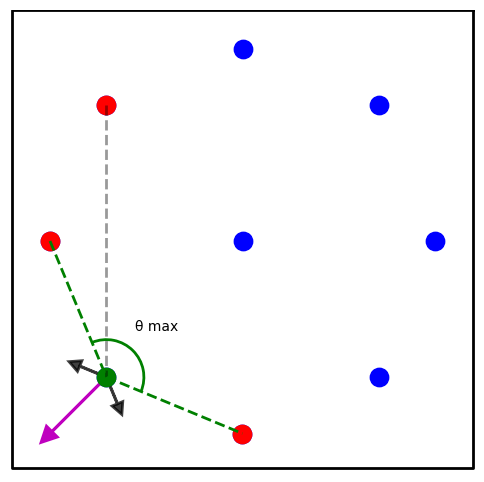

In [54]:
# Outer 2
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
fig = plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Find max angle between pairs of 2 neighbors and selected drone
# Draw combinations with lines
plt.plot([x[neighbors[0]], x[selected]], [y[neighbors[0]], y[selected]], c='k', linestyle='--', lw=2, alpha=0.4)
plt.plot([x[neighbors[1]], x[selected], x[neighbors[2]]], [y[neighbors[1]], y[selected], y[neighbors[2]]], c='green', linestyle='--', lw=2)

# Show arrows for max angle edges
dir = np.array([x[neighbors[1]] - x[selected], y[neighbors[1]] - y[selected]])
dir = -dir / np.linalg.norm(dir)
plt.arrow(x[selected], y[selected], dir[0]*0.075, dir[1]*0.075, head_width=0.03, head_length=0.03, fc='k', ec='k', lw=2, alpha=0.75)
dir2 = np.array([x[neighbors[2]] - x[selected], y[neighbors[2]] - y[selected]])
dir2 = -dir2 / np.linalg.norm(dir2)
plt.arrow(x[selected], y[selected], dir2[0]*0.075, dir2[1]*0.075, head_width=0.03, head_length=0.03, fc='k', ec='k', lw=2, alpha=0.75)

# Draw pointing arrow
final_dir = (dir + dir2) / 2
final_dir = final_dir / np.linalg.norm(final_dir)
plt.arrow(x[selected], y[selected], final_dir[0]*0.2, final_dir[1]*0.2, head_width=0.04, head_length=0.04, fc='m', ec='m', lw=2)

# Add angle anotation
AngleAnnotation(xy=(x[selected], y[selected]), p2=(x[neighbors[1]], y[neighbors[1]]), p1=(x[neighbors[2]], y[neighbors[2]]), size=75, ax=fig.gca(), color='g', lw=2, text="θ max", textposition="outside", text_kw={"color": "k"})

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)

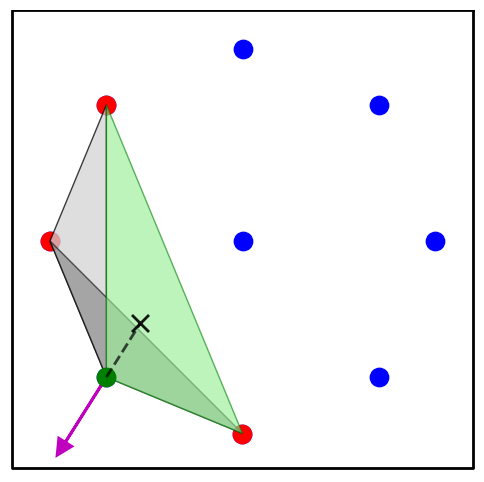

In [66]:
# Outer 3
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
fig = plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Draw sets of triangles with neighbors
t1 = np.array([[x[selected], y[selected]], [x[neighbors[0]], y[neighbors[0]]], [x[neighbors[1]], y[neighbors[1]]], [x[selected], y[selected]]])
t2 = np.array([[x[selected], y[selected]], [x[neighbors[1]], y[neighbors[1]]], [x[neighbors[2]], y[neighbors[2]]], [x[selected], y[selected]]])
t3 = np.array([[x[selected], y[selected]], [x[neighbors[2]], y[neighbors[2]]], [x[neighbors[0]], y[neighbors[0]]], [x[selected], y[selected]]])
plt.fill(t1[:, 0], t1[:, 1], facecolor='lightgrey', edgecolor='k', alpha=0.75)
plt.fill(t2[:, 0], t2[:, 1], facecolor='grey', edgecolor='k', alpha=0.6)
plt.fill(t3[:, 0], t3[:, 1], facecolor='lightgreen', edgecolor='green', alpha=0.6)

# find centroid of triangle
centroid = np.mean(t3, axis=0)
plt.scatter(centroid[0], centroid[1], marker='x', color=[[0,0,0,0.90]], s=150, linewidth=2)
plt.plot([x[selected], centroid[0]], [y[selected], centroid[1]], 'k--', lw=2, alpha=0.7)

# Draw pointing arrow
final_dir = np.array([centroid[0] - x[selected], centroid[1] - y[selected]])
final_dir = - final_dir / np.linalg.norm(final_dir)
plt.arrow(x[selected], y[selected], final_dir[0]*0.2, final_dir[1]*0.2, head_width=0.04, head_length=0.04, fc='m', ec='m', lw=2)


plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)

4. Tangent plane

[0.04587585 0.45412415]
[[-0.88807383  0.45970084]
 [-0.45970084 -0.88807383]]


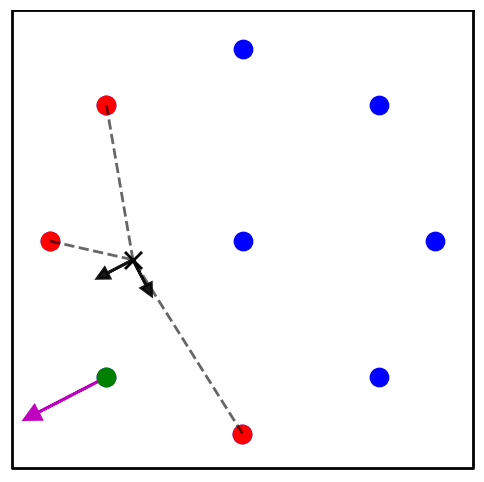

In [73]:
# Outer 3
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
fig = plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

neighbors_pos = np.array([[x[i], y[i]] for i in neighbors])
drone_pos = np.array([x[selected], y[selected]])
centroid = np.mean(neighbors_pos, axis=0)
neighbors_centered = neighbors_pos - centroid
cov = np.sum([np.outer(n, n) for n in neighbors_centered], axis=0)
eig_val, eig_vectors = np.linalg.eig(cov)
eig_val, eig_vectors = np.real(eig_val), np.real(eig_vectors)
print(eig_val)
print(eig_vectors)
sorted_indices = np.argsort(eig_val)
normal = eig_vectors[:,sorted_indices[0]]
if abs(eig_val[sorted_indices[1]] - eig_val[sorted_indices[0]]) < 0.01:
    print("WARNING :: Eigenvalues are too close to each other, averaging the two smallest")
    normal = np.mean(eig_vectors[:,sorted_indices[:2]], axis=0)

viewing_dir = -np.sign(np.dot(normal, centroid-drone_pos))*normal

# Show arrows for eigenvectors
plt.scatter(centroid[0], centroid[1], marker='x', color='k', s=150, linestyle='-', facecolor='k', linewidth=2)
# draw lines to centroid
for i in range(len(neighbors)):
    plt.plot([x[neighbors[i]], centroid[0]], [y[neighbors[i]], centroid[1]], 'k--', alpha=0.6, lw=2)
dir = eig_vectors[:,sorted_indices[0]]
plt.arrow(centroid[0], centroid[1], dir[0]*0.075, dir[1]*0.075, head_width=0.03, head_length=0.03, fc='k', ec='k', lw=2, alpha=0.9)
dir2 = eig_vectors[:,sorted_indices[1]]
plt.arrow(centroid[0], centroid[1], dir2[0]*0.075, dir2[1]*0.075, head_width=0.03, head_length=0.03, fc='k', ec='k', lw=2, alpha=0.9)

# Draw pointing arrow
final_dir = viewing_dir
final_dir = final_dir / np.linalg.norm(final_dir)
plt.arrow(x[selected], y[selected], final_dir[0]*0.2, final_dir[1]*0.2, head_width=0.04, head_length=0.04, fc='m', ec='m', lw=2)


plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)

ValueError: shapes (27,) and (3,9) not aligned: 27 (dim 0) != 3 (dim 0)

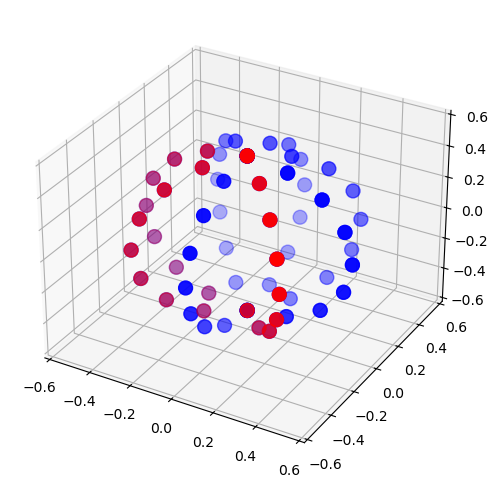

In [174]:
# 3D tangent plane viewing dir
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 175
# 8 drones on a sphere + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions distibuted on a sphere
theta = np.linspace(0, np.pi, n)
phi = np.linspace(0, 2*np.pi, n)
theta, phi = np.meshgrid(theta, phi)
x = r*np.sin(theta)*np.cos(phi)
y = r*np.sin(theta)*np.sin(phi)
z = r*np.cos(theta)

# Set figure
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([-BOUND, BOUND])
ax.set_ylim([-BOUND, BOUND])
ax.set_zlim([-BOUND, BOUND])
# Hide axes
# ax.axis('off')
# Scatter plot
ax.scatter(x, y, z, marker='o', color='b', s=SIZE)
ax.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], [z[i] for i in neighbors], marker='o', color='r', s=SIZE)

neighbors_pos = np.array([[x[i], y[i], z[i]] for i in neighbors])
drone_pos = np.array([x[selected], y[selected], z[selected]])
centroid = np.mean(neighbors_pos, axis=0)
neighbors_centered = neighbors_pos - centroid
cov = np.sum([np.outer(n, n) for n in neighbors_centered], axis=0)
eig_val, eig_vectors = np.linalg.eig(cov)
eig_val, eig_vectors = np.real(eig_val), np.real(eig_vectors)
sorted_indices = np.argsort(eig_val)
normal = eig_vectors[sorted_indices[0]]
if abs(eig_val[sorted_indices[1]] - eig_val[sorted_indices[0]]) < 0.01:
    print("WARNING :: Eigenvalues are too close to each other, averaging the two smallest")
    normal = np.mean(eig_vectors[sorted_indices[:2]], axis=0)

viewing_dir = -np.sign(np.dot(normal, centroid-drone_pos))*normal

# Show arrows for eigenvectors
ax.scatter(centroid[0], centroid[1], centroid[2], marker='o', color='k', s=100, linestyle='-', facecolor='lightgray', linewidth=1.5)
# draw lines to centroid
for i in range(len(neighbors)):
    ax.plot([x[neighbors[i]], centroid[0]], [y[neighbors[i]], centroid[1]], [z[neighbors[i]], centroid[2]], 'k--', alpha=0.6, lw=1)

dir = eig_vectors[sorted_indices[0]]
ax.quiver(centroid[0], centroid[1], centroid[2], dir[0]*0.05, dir[1]*0.05, dir[2]*0.05, color='k')
dir2 = eig_vectors[sorted_indices[1]]
ax.quiver(centroid[0], centroid[1], centroid[2], dir2[0]*0.05, dir2[1]*0.05, dir2[2]*0.05, color='k')

# Draw pointing arrow
final_dir = viewing_dir
final_dir = final_dir / np.linalg.norm(final_dir)
ax.quiver(x[selected], y[selected], z[selected], final_dir[0]*0.2, final_dir[1]*0.2, final_dir[2]*0.2, color='m')


ax.scatter(x[selected], y[selected], z[selected], marker='o', color='g', s=SIZE)

### Concave idea example

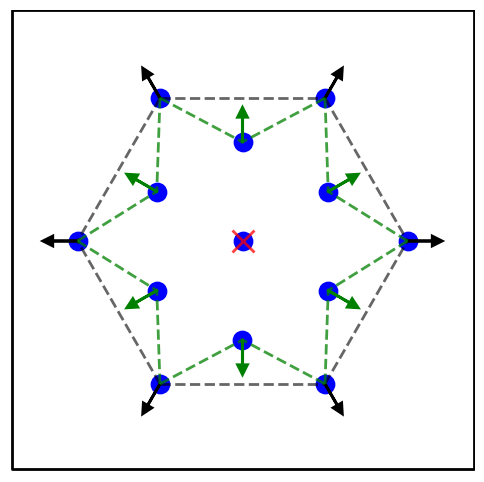

In [84]:
# Simple average of neighbors
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.7
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 13
r = 0.5
r_inner = 0.3
inner_idx = [1,3,5,7,9,11]
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r_inner*np.cos(2*np.pi*i/(n-1)) if i in inner_idx else r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r_inner*np.sin(2*np.pi*i/(n-1)) if i in inner_idx else r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')

# Draw convex hull with dotted line of all points
from scipy.spatial import ConvexHull
points = np.array([[x[i], y[i]] for i in range(n)])
hull = ConvexHull(points)
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k--', alpha=0.6, lw=2)

# Add triangles to fir inner ring to outter ring with dotted line
for i in range(len(inner_idx)):
    plt.plot([x[inner_idx[i]], x[inner_idx[i]+1]], [y[inner_idx[i]], y[inner_idx[i]+1]], 'g--', alpha=0.75, lw=2)
for i in range(1,len(inner_idx)):
    plt.plot([x[inner_idx[i]], x[inner_idx[i]-1]], [y[inner_idx[i]], y[inner_idx[i]-1]], 'g--', alpha=0.75, lw=2)
plt.plot([x[inner_idx[0]], x[-1]], [y[inner_idx[0]], y[-1]], 'g--', alpha=0.75, lw=2)

# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)

# Add x mark to center drone
plt.scatter(x[0], y[0], marker='x', color=[[1,0,0,0.75]], s=250, linewidth=2)

# Add arrows for points on convex hull pointing away on the outter points
for i in hull.vertices:
    dir = np.array([x[i] - x[0], y[i] - y[0]])
    dir = dir / np.linalg.norm(dir)
    plt.arrow(x[i], y[i], dir[0]*0.075, dir[1]*0.075, head_width=0.03, head_length=0.03, fc='k', ec='k', lw=2)

# Add arrows for points on convex hull pointing away on the inner points
for i in range(1,n):
    if i not in inner_idx:
        dir = np.array([x[i] - x[0], y[i] - y[0]])
        dir = dir / np.linalg.norm(dir)
        plt.arrow(x[i], y[i], dir[0]*0.075, dir[1]*0.075, head_width=0.03, head_length=0.03, fc='g', ec='g', lw=2)


# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)

C:\Users\alexa\AppData\Local\Temp\ipykernel_296\1097980764.py:32: RuntimeWarning: invalid value encountered in divide
  dir = dir / np.linalg.norm(dir)
C:\Users\alexa\AppData\Local\Temp\ipykernel_296\1097980764.py:39: RuntimeWarning: invalid value encountered in divide
  dir = dir / np.linalg.norm(dir)


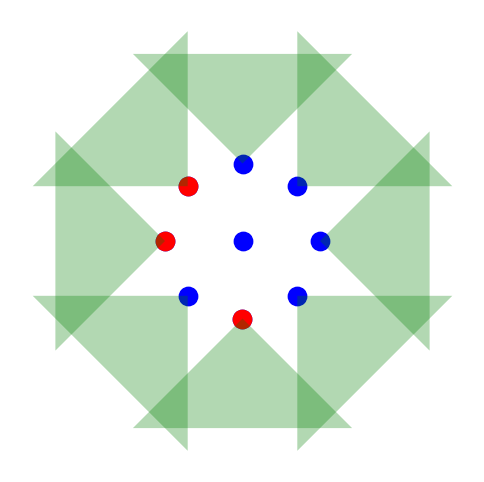

In [123]:
# generate figure for coverage metric with drone FOV
import numpy as np
import matplotlib.pyplot as plt

BOUND = 1.5
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Draw FOV for all drones at drone location towards outside of circle
fov = 2*np.pi/4
for i in range(n):
    dir = np.array([x[i] - x[0], y[i] - y[0]])
    dir = dir / np.linalg.norm(dir)
    angle = np.arctan2(dir[1], dir[0])
    plt.fill([x[i], x[i] + np.cos(angle-fov/2), x[i] + np.cos(angle+fov/2)], [y[i], y[i] + np.sin(angle-fov/2), y[i] + np.sin(angle+fov/2)], 'g', alpha=0.3)

# Show overlapping region for all drones
for i in range(n):
    dir = np.array([x[i] - x[0], y[i] - y[0]])
    dir = dir / np.linalg.norm(dir)
    angle = np.arctan2(dir[1], dir[0])

#plt.fill([x[0], x[0] + np.cos(-fov), x[0] + np.cos(0)], [y[0], y[0] + np.sin(-fov), y[0] + np.sin(0)], 'r', alpha=0.3)

C:\Users\alexa\AppData\Local\Temp\ipykernel_296\3124815718.py:32: RuntimeWarning: invalid value encountered in divide
  dir = dir / np.linalg.norm(dir)


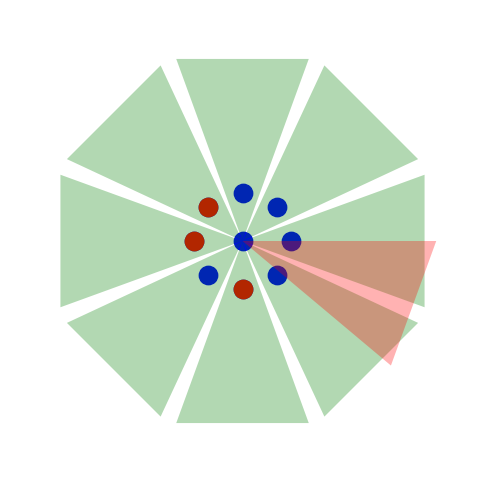

In [112]:
# generate figure for coverage metric with drone FOV
import numpy as np
import matplotlib.pyplot as plt

BOUND = 1.2
SIZE = 175
# 8 drones on a circle + 1 in the center
n = 9
r = 0.25
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Draw FOV for all drones at drone location towards outside of circle
fov = 2*np.pi/9
for i in range(n):
    dir = np.array([x[i] - x[0], y[i] - y[0]])
    dir = dir / np.linalg.norm(dir)
    angle = np.arctan2(dir[1], dir[0])
    plt.fill([x[0], x[0] + np.cos(angle-fov/2), x[0] + np.cos(angle+fov/2)], [y[0], y[0] + np.sin(angle-fov/2), y[0] + np.sin(angle+fov/2)], 'g', alpha=0.3)

plt.fill([x[0], x[0] + np.cos(-fov), x[0] + np.cos(0)], [y[0], y[0] + np.sin(-fov), y[0] + np.sin(0)], 'r', alpha=0.3)


## Noise test w/ Convex Hull Adjacent

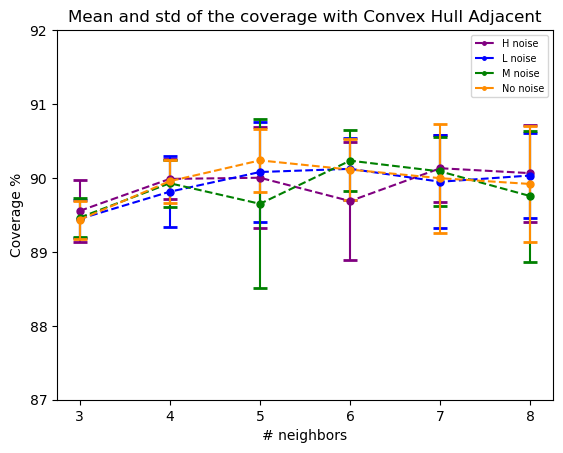

In [94]:
from matplotlib.collections import LineCollection
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib.colors import Normalize, ListedColormap
from matplotlib import container
import sys, os

NB_TESTS = 6
from_ = 3
to = 8
steps = 1

def generate_coverage_plot(all_swarm_data, ax):
    ax.set_title('Mean and std of the coverage with Convex Hull Adjacent')
    ax.set_xlabel('# neighbors')
    ax.set_ylabel('Coverage %')
    ax.set_ylim(87, 92)
    colors = ['purple', 'blue', 'green', 'darkorange', 'black']
    for n, key in enumerate(all_swarm_data.keys()):
        # Find the average coverage for each drone
        coverage_mean = np.array([np.mean(all_swarm_data[key][i]['viewing_coverage'], axis=0) for i in range(NB_TESTS)])
        coverage_std = np.array([np.std(all_swarm_data[key][i]['viewing_coverage'], axis=0) for i in range(NB_TESTS)])
        ax.errorbar(np.arange(from_, to+1, steps), coverage_mean*100, yerr=[coverage_std*100, np.clip(coverage_std, 0, 1-coverage_mean)*100], fmt='--', label=f"{key.replace('_', ' ')}", markersize=5, marker='o', ecolor=colors[n], color=colors[n], capsize=5, capthick=2)
    # Filter out error bars from legend
    handles, labels = ax.get_legend_handles_labels()
    handles = [h[0] if isinstance(h, container.ErrorbarContainer) else h for h in handles]
    ax.legend(handles, labels, fontsize=7, draggable=True, markerscale=0.5, loc='best')

FOLDER = "../sim_results/2D_convexhull_adj_noise"

# Read all files in the folder
all_data = {}
for dir in os.listdir(FOLDER):
    if os.path.isdir(os.path.join(FOLDER, dir)):
        all_data[dir] = []
        files = os.listdir(os.path.join(FOLDER, dir))
        # Sort files by number
        files.sort(key=lambda x: int(x.split('_')[-1].split('.')[0]))
        for file in files:
            if file.endswith('.npy'):
                all_data[dir].append(np.load(os.path.join(FOLDER, dir, file), allow_pickle=True).item())

# Create dictionnary with all swarm data
all_swarm_data = {}
for key in all_data.keys():
    all_swarm_data[key] = []
    for i in range(NB_TESTS):
        all_swarm_data[key].append(all_data[key][i]['swarm_data'])

# Generate figure
fig, ax = plt.subplots()
generate_coverage_plot(all_swarm_data, ax)


## Second test: Remaining of metrics

The following table summarizes the scheduled tests:


| **Test metric** | **from** | **to** | **incremnents** |       **Fixed parameters**                |  **Cumulative sim run** |
|-----------------|----------|--------|-----------------|-------------------------------------------|-------------------------|
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Average                |           6             |
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Tangeant plane         |           12            |
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Convex Hull (Adjacent) |           18            |
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Convex Hull (Visible)  |           24            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Average                    |           30            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Tangeant plane             |           36            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Convex Hull (Adjacent)     |           42            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Convex Hull (Visible)      |           48            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Average                       |           54            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Tangeant plane                |           60            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Convex Hull (Adjacent)        |           66            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Convex Hull (Visible)         |           72            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Low (0.01;0.01), Average        |           80            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Low (0.01;0.01), Tangean plane  |           88            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Low (0.01;0.01), Convex Hull    |           96            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Medium (0.025;0.025), Average    |           80            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Medium (0.025;0.025), Tangean plane |        88            |
|  # Neighbors    |     2    |  9     |         1       |    Noise:Medium (0.025;0.025), Convex Hull |           96            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: High (0.05;0.05), Average        |           102           |
|  # Neighbors    |     2    |  9     |         1       |    Noise: High (0.05;0.05), Tangean plane  |           110           |
|  # Neighbors    |     2    |  9     |         1       |    Noise: High (0.05;0.05), Convex Hull    |           118           |

***NOTE:*** This table should be reproduced twice for 2D and 3D swarm configurations

**Total graphs:** 2*24 = **48**
